In [11]:
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

print(f"Forma de los datos: {X.shape}")
print(f"Estructura de las etiquetas: {y.shape}")

Forma de los datos: (70000, 784)
Estructura de las etiquetas: (70000,)


Etiqueta de la imagen: 6


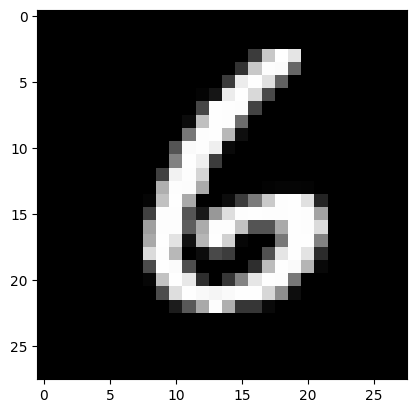

In [12]:
imagen = X[6000].reshape(28,28)
etiqueta = y[6000]

print(f"Etiqueta de la imagen: {etiqueta}")
plt.imshow(imagen, cmap="gray")
plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=5
)

X_train = X_train[:1000]
y_train = y_train[:1000]

X_test = X_test[:1000]
y_test = y_test[:1000]


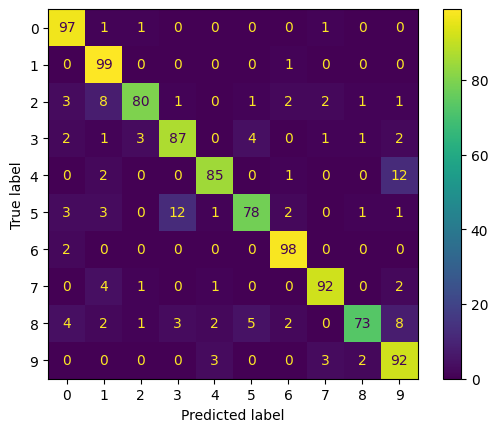

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Definimos el modelo KNN
knn = KNeighborsClassifier(n_neighbors=3)

# Entrenamiento
knn.fit(X_train, y_train)

# Predicción
y_pred = knn.predict(X_test)

# 🔴 CAMBIO: normalizar, convertir a %, y redondear a enteros
cfn_mat = confusion_matrix(y_test, y_pred, normalize='true') * 100
cfn_mat = np.round(cfn_mat).astype(int)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cfn_mat,
    display_labels=knn.classes_
)

disp.plot(values_format="d")  # formato entero
plt.show()

In [19]:
from sklearn.metrics import classification_report

rp = classification_report(y_test, y_pred)
print(rp)

              precision    recall  f1-score   support

           0       0.86      0.97      0.91        88
           1       0.84      0.99      0.91       105
           2       0.92      0.80      0.86        90
           3       0.85      0.87      0.86       110
           4       0.92      0.85      0.88        94
           5       0.90      0.78      0.83       110
           6       0.92      0.98      0.95       100
           7       0.93      0.92      0.93       101
           8       0.94      0.73      0.82       101
           9       0.79      0.92      0.85       101

    accuracy                           0.88      1000
   macro avg       0.89      0.88      0.88      1000
weighted avg       0.89      0.88      0.88      1000

